--- Dataset Preview ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


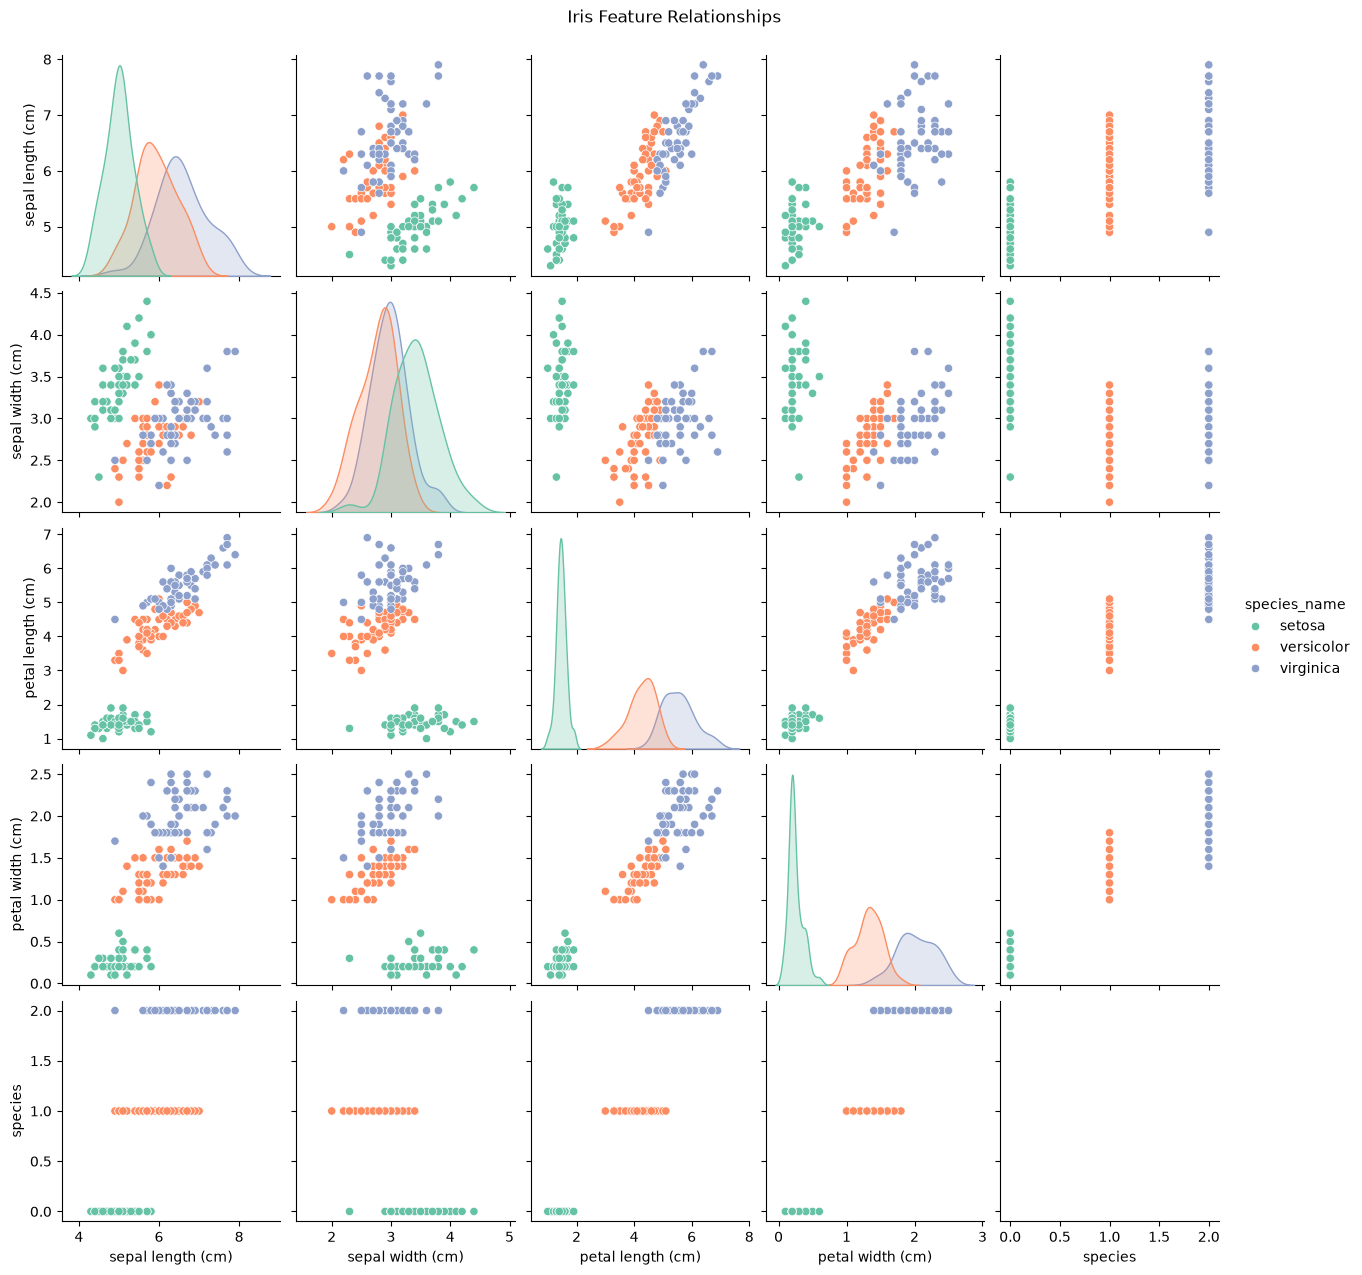

Successfully trained: K-Nearest Neighbors (KNN)
Successfully trained: Decision Tree
Successfully trained: Support Vector Machine (SVM)


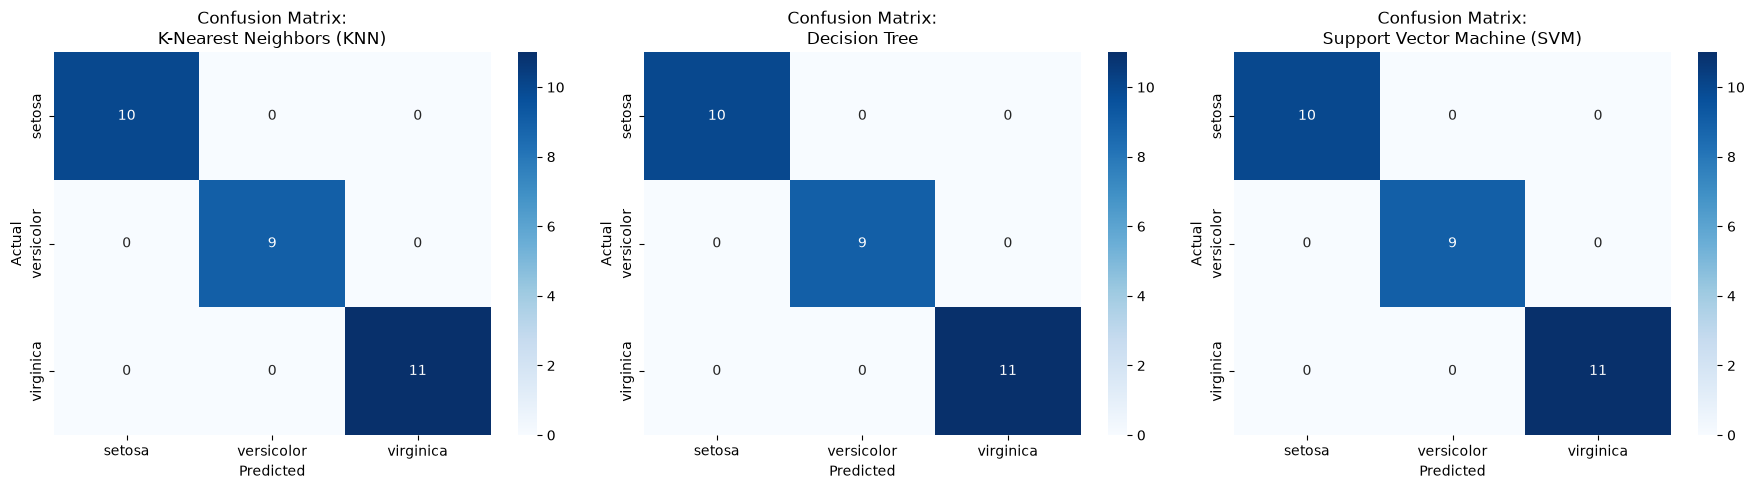


--- Model Performance Comparison ---
                       Model  Accuracy  Precision  Recall  F1-Score
   K-Nearest Neighbors (KNN)       1.0        1.0     1.0       1.0
               Decision Tree       1.0        1.0     1.0       1.0
Support Vector Machine (SVM)       1.0        1.0     1.0       1.0

--- Custom Value Prediction Example ---
Input: Sepal(5.1x3.5), Petal(1.4x0.2)
Predicted Species: SETOSA



In [ ]:
# =====================================================================
# 1. LOAD AND EXPLORE THE DATASET (EDA)
# =====================================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Load the classic Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["species"] = iris.target
df["species_name"] = df["species"].map(
    {i: name for i, name in enumerate(iris.target_names)}
)

print("--- Dataset Preview ---")
print(df.head())

# EDA Visualization
pair_plot = sns.pairplot(df, hue="species_name", diag_kind="kde", palette="Set2")
plt.suptitle("Iris Feature Relationships", y=1.02)

# --- FIRST IMAGE SAVE CHANGES HERE ---
# 1. Modati file 'iris_pairplot.png' ga save avthundhi
pair_plot.savefig('iris_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close() # Explicitly close the plot figure to free memory

# Split data into Features (X) and Target (y)
X = df[iris.feature_names]
y = df["species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================================================
# 2. TRAIN MODELS
# =====================================================================
models = {
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Support Vector Machine (SVM)": SVC(kernel="linear", random_state=42),
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(f"Successfully trained: {name}")

# =====================================================================
# 3. & 4. COMPARE METRICS & CONFUSION MATRIX
# =====================================================================
metrics_summary = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_pred) in enumerate(predictions.items()):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro")
    rec = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    metrics_summary.append(
        {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}
    )

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=iris.target_names,
        yticklabels=iris.target_names,
    )
    axes[i].set_title(f"Confusion Matrix:\n{name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()

# --- SECOND IMAGE SAVE CHANGES HERE ---
# 2. Rindava file 'confusion_matrices_output.png' ga save avthundhi
plt.savefig('confusion_matrices_output.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close() # Explicitly close the plot figure to free memory

df_metrics = pd.DataFrame(metrics_summary)
print("\n--- Model Performance Comparison ---")
print(df_metrics.to_string(index=False))

# =====================================================================
# 5. PREDICT SPECIES FOR CUSTOM INPUT VALUES
# =====================================================================
print("\n--- Custom Value Prediction Example ---")


def predict_custom_flower(sepal_len, sepal_wid, petal_len, petal_wid):
    chosen_model = models["Support Vector Machine (SVM)"]
    custom_data = pd.DataFrame(
        [[sepal_len, sepal_wid, petal_len, petal_wid]],
        columns=iris.feature_names,
    )
    prediction_id = chosen_model.predict(custom_data)
    predicted_species = iris.target_names[prediction_id]
    print(f"Input: Sepal({sepal_len}x{sepal_wid}), Petal({petal_len}x{petal_wid})")
    print(f"Predicted Species: {predicted_species[0].upper()}\n")


# Sample prediction
predict_custom_flower(5.1, 3.5, 1.4, 0.2)
